# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from typing import Optional

from collections import defaultdict
from enum import Enum
from datetime import datetime

import random
import numpy as np
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.providers import Backend
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import fake_provider
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.transpiler import PassManager, CouplingMap, passes
from qiskit.transpiler.passes import Optimize1qGatesDecomposition

DATA_PATH = os.path.join("..", "data")

## Noise models

In [2]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.

    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model    

In [3]:
def bitflip_model(p: float) -> NoiseModel:
    """Bitflip noise model with majority vote approach.

    Args:
        p: Probability to flip.
    Returns:
        Bit-flip noise model.
    """
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
    error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

## Constants

In [4]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3

# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [5]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
BETA = np.deg2rad(175)

## Expectation values

In [6]:
def decode_results(results: dict, charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1

            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")

                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]

    return decoded_results

In [7]:
def double_expect(settings: tuple[int, int], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)

## State preparation

In [8]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [9]:
def cnot_ladder(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

In [10]:
def cnot_ladder_random(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard) for random strategy."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [11]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)

def apply_setting(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  angle: float, 
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting is PEEK:
        if strategy == "majority_vote":
            # Ask friend for the outcome.
            qc.measure(friend_qubits, observer_creg)
        elif strategy == "random":
            random_offset = random.randint(0, friend_size - 1)
            qc.measure(friend_qubits[0] + random_offset, observer)

    elif setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)
        elif strategy == "random":
            cnot_ladder_random(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)

        if observer is BOB:
            qc.h(BOB)
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)

        if strategy == "majority_vote":
            qc.measure(observer, observer_creg)
        elif strategy == "random":
            qc.measure(observer, observer)


def ewfs(alice_setting: int,
        bob_setting: int,
        strategy: str,
        angles: list[float],
        beta: float,
        charlie_size: int,
        debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice's qubit", "Bob's qubit", "Charlie", "Debbie"])
    ]

    if strategy == "majority_vote":
        if (alice_setting == PEEK and bob_setting != PEEK):
            measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
            alice_creg = list(range(charlie_size))
            bob_creg = charlie_size
        else:
            measurement = ClassicalRegister(meas_size, name="Measurement")
            alice_creg = 0
            bob_creg = 1
    elif strategy == "random":
        measurement = ClassicalRegister(sys_size, name="Measurement")
        alice_creg, bob_creg = 0, 0
    else:
        raise ValueError(f"Strategy: {strategy} is not defined.")

    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = list(range(sys_size, (sys_size + charlie_size)))
    debbie_qubits = list(range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size)))

    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)

    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    if strategy == "majority_vote":
        cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
        cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)
    elif strategy == "random":
        cnot_ladder_random(qc, ALICE, charlie_qubits[0], charlie_size)
        cnot_ladder_random(qc, BOB, debbie_qubits[0], debbie_size)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, strategy, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, strategy, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    return qc

## Sanity checks (for majority vote approach)

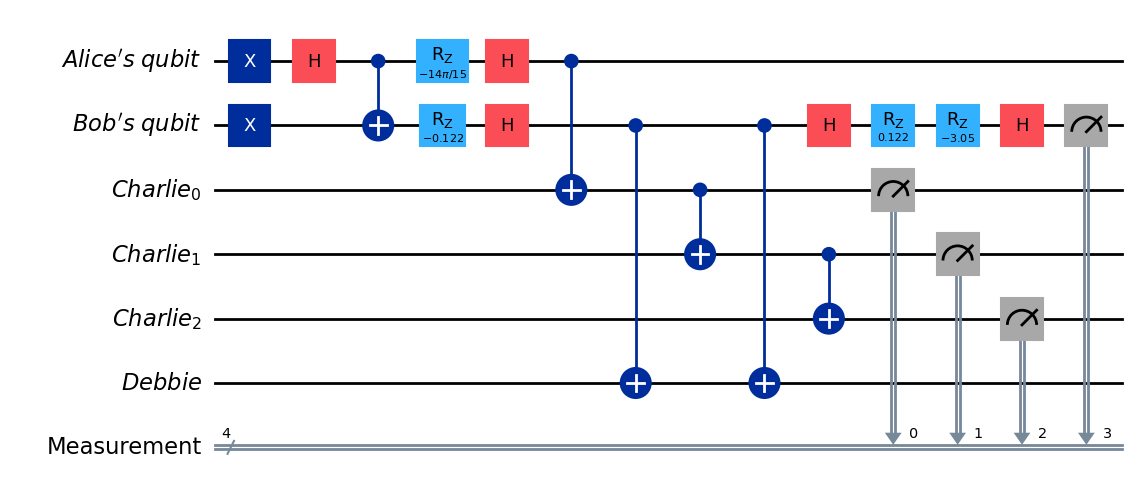

In [12]:
# Print example circuit.
charlie_size = 3
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
qc.draw("mpl", style="default")#.savefig("ewfs_majority_vote_peek_reverse_1.pdf")

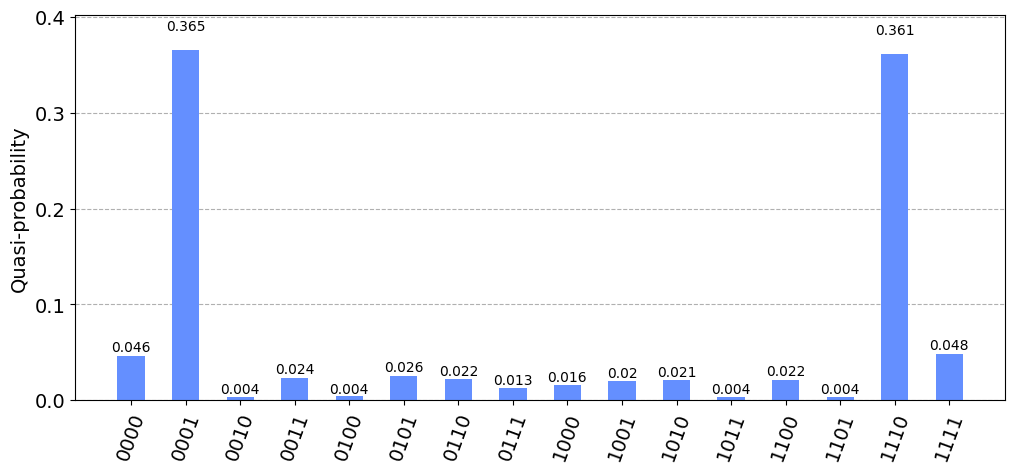

In [13]:
noise_bit_flip = bitflip_model(0.03)
simulator = AerSimulator(noise_model=noise_bit_flip)
transpiled_qc = transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

job = simulator.run(transpiled_qc, shots=10000)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / 10000 for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

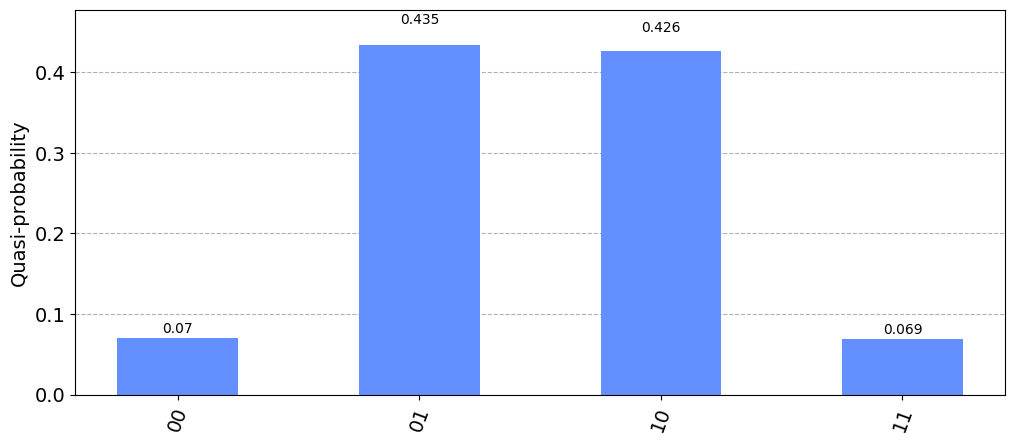

In [14]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

## Branch factor

In [15]:
# TODO: This needs to be more general.
def calculate_branch_factor(friend_size: int) -> float:
    return np.ceil(friend_size / 2) - 1

## File I/O

In [16]:
def save_data(
    results: dict,
    backend: Backend,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    backend_name: Optional[str] = None,
    data_path: str = DATA_PATH,
):
    """Writes data to a file name format of `<MACHINE_NAME>_qubits_<NUM_QUBITS>_trial_<NUM_TRIALS>_shots_<NUM_SHOTS>`."""
    if backend_name is None:
        backend_name = backend.name

    for friend_size in friend_sizes:
        qubits = friend_size

        # If not output file name is given, use this format.
        output_file_name = f"{backend_name}_qubits_{qubits}_trial_{num_trials}_shots_{shots}.pickle"
        output_path = os.path.join(data_path, output_file_name)

        print(f"Writing data to: {output_path}")
        with open(output_path, "wb") as handle:
            pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [19]:
def load_experiments(
    machine_name: str,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    strategy: str,
    data_path: str = DATA_PATH,
) -> dict:
    """Load experiments from multiple files."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        for trial in range(1, num_trials+1):
            with open(os.path.join(data_path, f"{machine_name}_qubits_{friend_size}_trial_{trial}_shots_{shots}.pickle"), "rb") as file:
                results = pickle.load(file)
            violations = compute_violations(results=results, charlie_size=friend_size, debbie_size=1, strategy=strategy)
            for key in violations:
                all_results[friend_size][key].append(violations[key])
    return all_results

## Inequalities

In [20]:
def compute_inequalities(results, verbose=False) -> dict[str, float]:
    """Compute the semi-Brukner inequalities."""
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)

    # Eq. (18) from [1].
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")

    return {"semi_brukner": semi_brukner}

In [21]:
def compute_violations(results: dict, charlie_size: int, debbie_size: int, strategy: str, verbose: bool = False) -> dict[str, float]:
    """Compute violation values based on strategy."""
    if strategy == "random":
        return compute_inequalities(results=results, verbose=verbose)
    elif strategy == "majority_vote":
        return compute_inequalities(decode_results(results=results, charlie_size=charlie_size, debbie_size=debbie_size), verbose=verbose)
    raise ValueError(f"Strategy: {strategy} not defined.")

## Experiment

### Transpilation layout optimization

In [22]:
def calculate_optimal_qubit_layout(backend_name: Optional[str], charlie_size: int) -> list[int]:
    """Target qubits for a specific topology with a chain-like connectivity.

    Function assumes that:
        1. Alice and Bob each have a single qubit.
        2. Debbie size is a single qubit.
        3. Charlie size is bounded by len(charlie_qubits).
    """
    fake_27_qubit_names = ["fake_kolkata", "fake_mumbai", "fake_hanoi", "fake_cairo"]
    real_27_qubit_names = ["ibmq_kolkata", "ibmq_mumbai", "ibm_hanoi", "ibm_cairo"]
    # 27-qubit IBM devices have qubit architectures that are all consistently oriented and labeled.
    if backend_name in fake_27_qubit_names or backend_name in real_27_qubit_names:
        # Refer to the Kolkata coupling map configuration:
        # https://quantum.ibm.com/services/resources?system=ibmq_kolkata
        alice_bob_qubits = [4, 1]
        debbie_qubits = [0]
        charlie_qubits = [7, 10, 12, 15, 18, 21, 23, 24, 25, 26, 22, 19, 20, 16]
        return alice_bob_qubits + charlie_qubits[:charlie_size] + debbie_qubits
    else:
        raise ValueError(f"Backend {backend_name} not supported.")

### Generate and run experiments

In [23]:
def generate_all_experiments(
    backend: Backend,
    backend_name: Optional[str],
    noise_model: Optional[NoiseModel],
    shots: int,
    strategy: str,
    angles: dict,
    beta: float,
    charlie_size: int,
    debbie_size: int,
    optimize: bool = True
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilities for all combinations of experimental settings."""
    all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]

    results = {}
    circuits = {}
    for alice, bob in all_experiment_combos:
        circuits[(alice, bob)] = ewfs(alice, bob, strategy, angles, beta, charlie_size, debbie_size)
    # Define pass manager for optimizing over single-qubit gates.
    pm = PassManager()
    pm.append(Optimize1qGatesDecomposition(["u", "u1", "u2", "u3", "p", "rx", "ry", "rz", "r", "sx", "x"]))

    # If optimize is True, we:
    # 1. Arrange the layout in a linear-like way depending on the architecture.
    # 2. Optimize single-qubit gate decompositions.
    if optimize:
        initial_layout = calculate_optimal_qubit_layout(backend_name, charlie_size)
        transpiled_circuits = transpile(
            list(circuits.values()),
            backend=backend,
            optimization_level=0,
            initial_layout=initial_layout,
        )
        transpiled_circuits = pm.run(transpiled_circuits)
    # Otherwise, we simply transpile the circuit without any optimizations.
    else:
        transpiled_circuits = transpile(
            list(circuits.values()),
            optimization_level=0,
            backend=backend
        )
    circuits = {key: circuit for key, circuit in zip(circuits.keys(), transpiled_circuits)}

    # Assuming the backend is AerSimulator if a noise model is provided
#    if noise_model:
#        backend = AerSimulator(noise_model=noise_model)

    result = backend.run(list(circuits.values()),
                         #noise_model=noise_model,
                         #basis_gates=noise_model.basis_gates if noise_model is not None else None,
                         shots=shots).result()
    # Convert counts to probabilities
    for key, count in zip(circuits.keys(), result.get_counts()):
        probabilities = {k[::-1]: v / shots for k, v in count.items()}
        results[key] = probabilities

    return results

In [24]:
def run_experiment(
    backend: Backend,
    noise_model: Optional[NoiseModel],
    friend_sizes: list[int],
    shots: int,
    strategy: str,
    backend_name: Optional[str] = None,
    num_trials: int = 1,
    verbose: bool = False,
    save: bool = False,
    optimize: bool = False,
) -> dict:
    """Run the main experiment for a specified backend."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }
    if backend_name is None:
        backend_name = backend.name

    # Create timestamped directory to save results.
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    new_dir_name = f"{strategy}_{backend_name}_{timestamp}"
    new_dir_path = os.path.join(DATA_PATH, new_dir_name)

    if not os.path.exists(new_dir_path):
        os.makedirs(new_dir_path)

    for friend_size in friend_sizes:
        print(f"{friend_size=}")
        for trial in range(num_trials):
            results = generate_all_experiments(
                backend=backend,
                backend_name=backend_name,
                noise_model=noise_model,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
                debbie_size=1,
                optimize=optimize,
                strategy=strategy,
            )
            violations = compute_violations(results=results, charlie_size=friend_size, debbie_size=1, strategy=strategy, verbose=verbose)
            for key in violations:
                all_results[friend_size][key].append(violations[key])

            # Save data after each trial of each friend_size
            if save:
                save_data(results=results,
                          backend=backend,
                          friend_sizes=[friend_size],
                          num_trials=trial + 1,
                          shots=shots,
                          data_path=new_dir_path,
                          backend_name=backend_name)
    return all_results

## Plotting

In [23]:
def plot_results(
    ax,
    results: dict, 
    friend_sizes: list[int], 
    plot_title: str,
    plot_error_bars: bool = False,
    color: str = "tab:blue",
    label: Optional[str] = None,
    show_legend: bool = False,
    marker: str = "o",
    marker_size: float = 10,
    line_width: float = 2.5,
    y_min: Optional[float] = None,
    y_max: Optional[float] = None,
):
    # Compute averages and standard deviations
    avg_results = {}
    std_results = {}
    for fs in results:
        avg_results[fs] = {}
        std_results[fs] = {}
        for key in results[fs]:
            avg_results[fs][key] = np.mean(results[fs][key])
            if plot_error_bars:
                std_results[fs][key] = np.std(results[fs][key])

    for _, key in enumerate(["semi_brukner"]):
        means = [np.mean(results[fs][key]) for fs in friend_sizes]
        errors = [np.std(results[fs][key]) for fs in friend_sizes] if plot_error_bars else None
        ax.plot(
            friend_sizes,
            means,
            label=label,
            marker=marker,
            markersize=marker_size,
            linestyle="-",
            linewidth=line_width,
            color=color,
        )
        if plot_error_bars:
            ax.errorbar(friend_sizes, means, yerr=errors, fmt="none", color=color, capsize=5, elinewidth=line_width)

    ax.axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
    ax.axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)

    ax.set_xticks(friend_sizes)
    ax.set_title(plot_title)
    ax.grid(True)

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)    

    if show_legend:
        ax.legend()

## Plotting loaded data

### Plot: Majority vote vs. Random (Simulator)

In [124]:
# Load simulator data (majority vote)
ideal_sim_name_majority_vote = "ideal_simulator"
ideal_sim_friend_sizes_majority_vote = range(1, 13)
ideal_sim_num_trials_majority_vote = 10
ideal_sim_shots_majority_vote = 10000
ideal_sim_results_majority_vote = load_experiments(ideal_sim_name_majority_vote, ideal_sim_friend_sizes_majority_vote, ideal_sim_num_trials_majority_vote, ideal_sim_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ideal_simulator_20240312-090228"))

depolarizing_1perc_name_majority_vote = "depolarizing_1perc"
depolarizing_1perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_1perc_num_trials_majority_vote = 10
depolarizing_1perc_shots_majority_vote = 10000
depolarizing_1perc_results_majority_vote = load_experiments(depolarizing_1perc_name_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, depolarizing_1perc_num_trials_majority_vote, depolarizing_1perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_1perc_20240312-090246"))

depolarizing_2perc_name_majority_vote = "depolarizing_2perc"
depolarizing_2perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_2perc_num_trials_majority_vote = 10
depolarizing_2perc_shots_majority_vote = 10000
depolarizing_2perc_results_majority_vote = load_experiments(depolarizing_2perc_name_majority_vote, depolarizing_2perc_friend_sizes_majority_vote, depolarizing_2perc_num_trials_majority_vote, depolarizing_2perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_2perc_20240312-091726"))

depolarizing_3perc_name_majority_vote = "depolarizing_3perc"
depolarizing_3perc_friend_sizes_majority_vote = range(1, 13)
depolarizing_3perc_num_trials_majority_vote = 10
depolarizing_3perc_shots_majority_vote = 10000
depolarizing_3perc_results_majority_vote = load_experiments(depolarizing_3perc_name_majority_vote, depolarizing_3perc_friend_sizes_majority_vote, depolarizing_3perc_num_trials_majority_vote, depolarizing_3perc_shots_majority_vote, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_3perc_20240312-093153"))

# Load simulator data (random)
ideal_sim_name_random = "ideal_simulator"
ideal_sim_friend_sizes_random = range(1, 13)
ideal_sim_num_trials_random = 10
ideal_sim_shots_random = 10000
ideal_sim_results_random = load_experiments(ideal_sim_name_random, ideal_sim_friend_sizes_random, ideal_sim_num_trials_random, ideal_sim_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_ideal_simulator_20240312-150903"))

depolarizing_1perc_name_random = "depolarizing_1perc"
depolarizing_1perc_friend_sizes_random = range(1, 13)
depolarizing_1perc_num_trials_random = 10
depolarizing_1perc_shots_random = 10000
depolarizing_1perc_results_random = load_experiments(depolarizing_1perc_name_random, depolarizing_1perc_friend_sizes_random, depolarizing_1perc_num_trials_random, depolarizing_1perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_1perc_20240312-150919"))

depolarizing_2perc_name_random = "depolarizing_2perc"
depolarizing_2perc_friend_sizes_random = range(1, 13)
depolarizing_2perc_num_trials_random = 10
depolarizing_2perc_shots_random = 10000
depolarizing_2perc_results_random = load_experiments(depolarizing_2perc_name_random, depolarizing_2perc_friend_sizes_random, depolarizing_2perc_num_trials_random, depolarizing_2perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_2perc_20240312-152151"))

depolarizing_3perc_name_random = "depolarizing_3perc"
depolarizing_3perc_friend_sizes_random = range(1, 13)
depolarizing_3perc_num_trials_random = 10
depolarizing_3perc_shots_random = 10000
depolarizing_3perc_results_random = load_experiments(depolarizing_3perc_name_random, depolarizing_3perc_friend_sizes_random, depolarizing_3perc_num_trials_random, depolarizing_3perc_shots_random, strategy="random", data_path=os.path.join(DATA_PATH, "random_depolarizing_3perc_20240312-153247"))

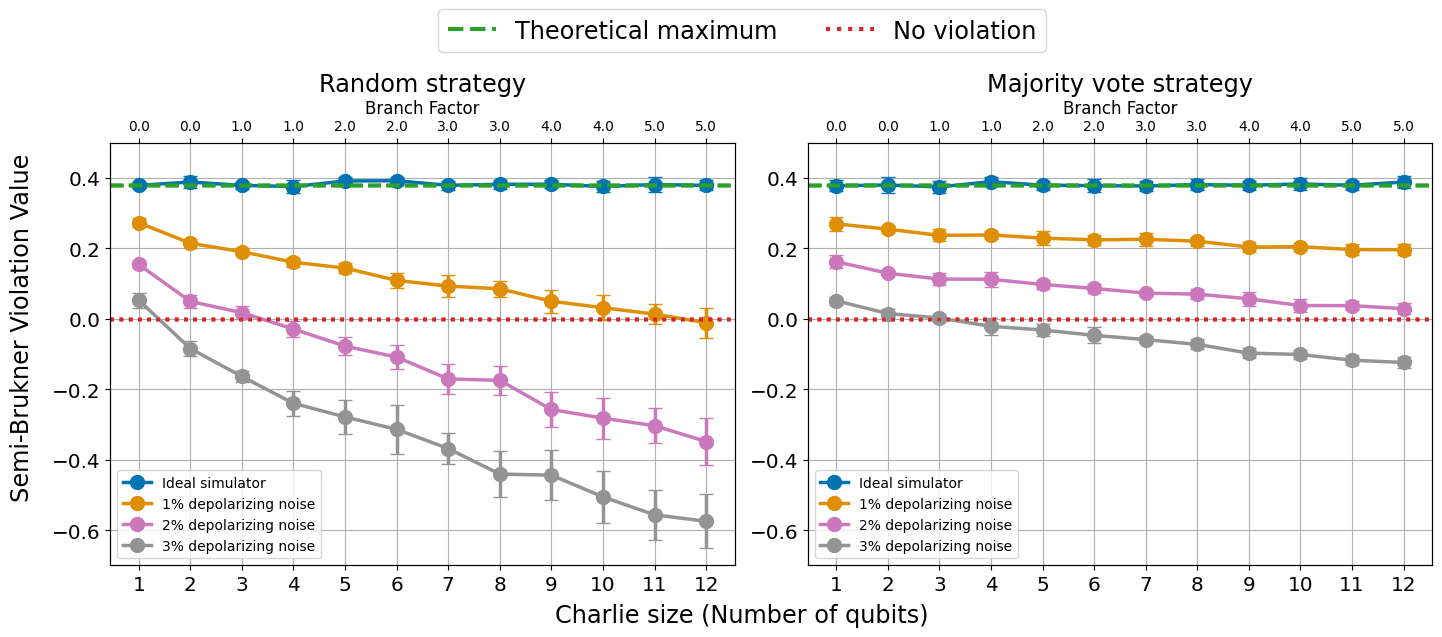

In [125]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

# Simulator plots
plot_results(axs[0], ideal_sim_results_random, ideal_sim_friend_sizes_random, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-0.7, y_max=0.5)
plot_results(axs[0], depolarizing_1perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_2perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_3perc_results_random, depolarizing_1perc_friend_sizes_random, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

plot_results(axs[1], ideal_sim_results_majority_vote, ideal_sim_friend_sizes_majority_vote, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-0.7, y_max=0.5)
plot_results(axs[1], depolarizing_1perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[1], depolarizing_2perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[1], depolarizing_3perc_results_majority_vote, depolarizing_1perc_friend_sizes_majority_vote, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

axs[0].set_title("Random strategy", fontsize="xx-large")
axs[1].set_title("Majority vote strategy", fontsize="xx-large")

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Charlie size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

ax2 = axs[0].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes_random]
ax2.set_xlim(axs[0].get_xlim())
ax2.set_xticks(ideal_sim_friend_sizes_random)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

ax2 = axs[1].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes_majority_vote]
ax2.set_xlim(axs[1].get_xlim())
ax2.set_xticks(ideal_sim_friend_sizes_majority_vote)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_strategy_simulator_comparison.pdf", bbox_inches="tight")
plt.show()

### Plot: Hardware vs. Fake vs. Simulator

In [204]:
# Load hardware data
kolkata_machine_name = "ibmq_kolkata"
kolkata_friend_sizes = range(1, 11)
kolkata_num_trials = 10
kolkata_shots = 10000
kolkata_results = load_experiments(kolkata_machine_name, kolkata_friend_sizes, kolkata_num_trials, kolkata_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ibmq_kolkata_chain_like_layout_20240316-114534"))

mumbai_machine_name = "ibmq_mumbai"
mumbai_friend_sizes = range(1, 9)
mumbai_num_trials = 10
mumbai_shots = 10000
mumbai_results = load_experiments(mumbai_machine_name, mumbai_friend_sizes, mumbai_num_trials, mumbai_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote"))

osaka_machine_name = "ibm_osaka"
osaka_friend_sizes = range(1, 9)
osaka_num_trials = 5
osaka_shots = 10000
osaka_results = load_experiments(osaka_machine_name, osaka_friend_sizes, osaka_num_trials, osaka_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote"))

kyoto_machine_name = "ibm_kyoto"
kyoto_friend_sizes = range(1, 9)
kyoto_num_trials = 5
kyoto_shots = 10000
kyoto_results = load_experiments(kyoto_machine_name, kyoto_friend_sizes, kyoto_num_trials, kyoto_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote"))

# Load fake data
fake_kolkata_machine_name = "fake_kolkata"
fake_kolkata_friend_sizes = range(1, 12)
fake_kolkata_num_trials = 10
fake_kolkata_shots = 10000
fake_kolkata_results = load_experiments(fake_kolkata_machine_name, fake_kolkata_friend_sizes, fake_kolkata_num_trials, fake_kolkata_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_kolkata_20240316-095152"))

fake_mumbai_machine_name = "fake_mumbai"
fake_mumbai_friend_sizes = range(1, 12)
fake_mumbai_num_trials = 10
fake_mumbai_shots = 10000
fake_mumbai_results = load_experiments(fake_mumbai_machine_name, fake_mumbai_friend_sizes, fake_mumbai_num_trials, fake_mumbai_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_mumbai_20240316-112633"))

fake_hanoi_machine_name = "fake_hanoi"
fake_hanoi_friend_sizes = range(1, 12)
fake_hanoi_num_trials = 10
fake_hanoi_shots = 10000
fake_hanoi_results = load_experiments(fake_hanoi_machine_name, fake_hanoi_friend_sizes, fake_hanoi_num_trials, fake_hanoi_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_hanoi_20240316-102217"))

fake_cairo_machine_name = "fake_cairo"
fake_cairo_friend_sizes = range(1, 12)
fake_cairo_num_trials = 10
fake_cairo_shots = 10000
fake_cairo_results = load_experiments(fake_cairo_machine_name, fake_cairo_friend_sizes, fake_cairo_num_trials, fake_cairo_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_fake_cairo_20240316-105322"))

# Load simulator data
ideal_sim_name = "ideal_simulator"
ideal_sim_friend_sizes = range(1, 13)
ideal_sim_num_trials = 10
ideal_sim_shots = 10000
ideal_sim_results = load_experiments(ideal_sim_name, ideal_sim_friend_sizes, ideal_sim_num_trials, ideal_sim_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_ideal_simulator_20240312-090228"))

depolarizing_1perc_name = "depolarizing_1perc"
depolarizing_1perc_friend_sizes = range(1, 13)
depolarizing_1perc_num_trials = 10
depolarizing_1perc_shots = 10000
depolarizing_1perc_results = load_experiments(depolarizing_1perc_name, depolarizing_1perc_friend_sizes, depolarizing_1perc_num_trials, depolarizing_1perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_1perc_20240312-090246"))

depolarizing_2perc_name = "depolarizing_2perc"
depolarizing_2perc_friend_sizes = range(1, 13)
depolarizing_2perc_num_trials = 10
depolarizing_2perc_shots = 10000
depolarizing_2perc_results = load_experiments(depolarizing_2perc_name, depolarizing_2perc_friend_sizes, depolarizing_2perc_num_trials, depolarizing_2perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_2perc_20240312-091726"))

depolarizing_3perc_name = "depolarizing_3perc"
depolarizing_3perc_friend_sizes = range(1, 13)
depolarizing_3perc_num_trials = 10
depolarizing_3perc_shots = 10000
depolarizing_3perc_results = load_experiments(depolarizing_3perc_name, depolarizing_3perc_friend_sizes, depolarizing_3perc_num_trials, depolarizing_3perc_shots, strategy="majority_vote", data_path=os.path.join(DATA_PATH, "majority_vote_depolarizing_3perc_20240312-093153"))

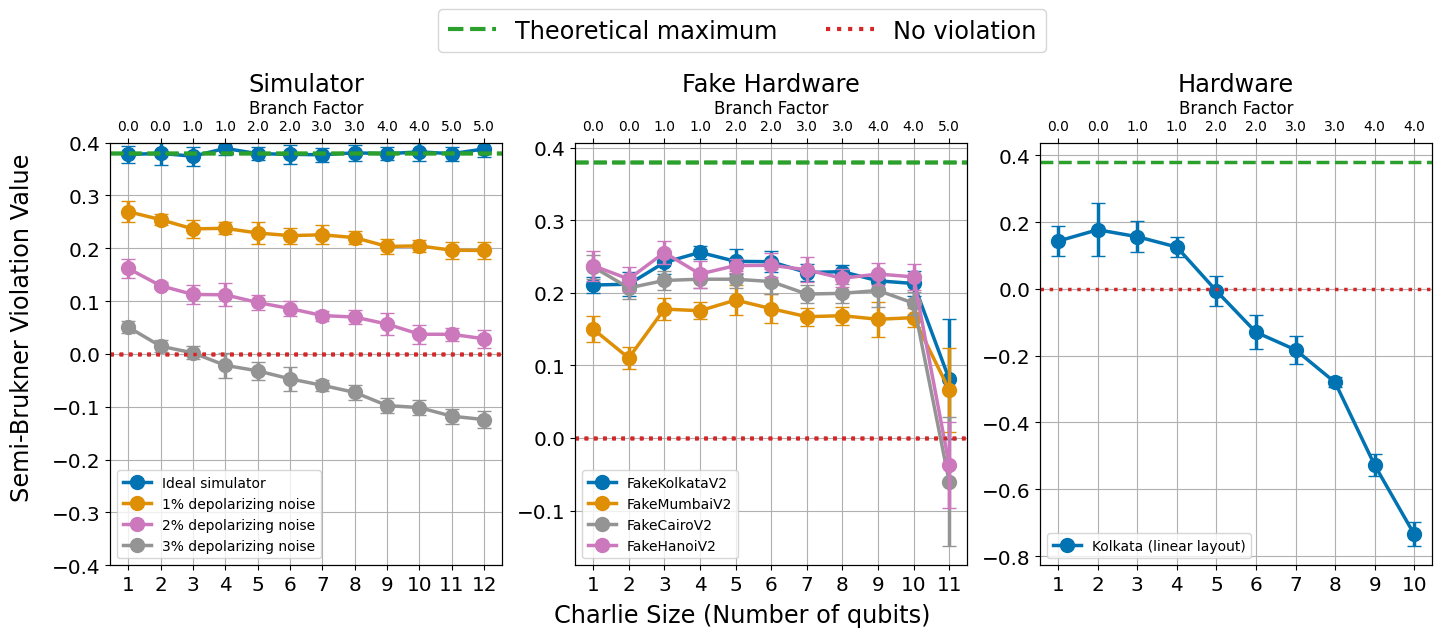

In [205]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

# Simulator plots
plot_results(axs[0], ideal_sim_results, ideal_sim_friend_sizes, plot_error_bars=True, plot_title="Ideal simulator", color=palette[0], label="Ideal simulator", show_legend=True, y_min=-0.4, y_max=0.4)
plot_results(axs[0], depolarizing_1perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="1% depolarizing noise", color=palette[1], label="1% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_2perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="2% depolarizing noise", color=palette[4], label="2% depolarizing noise", show_legend=True)
plot_results(axs[0], depolarizing_3perc_results, depolarizing_1perc_friend_sizes, plot_error_bars=True, plot_title="3% depolarizing noise", color=palette[7], label="3% depolarizing noise", show_legend=True)

# Fake hardware plots
plot_results(axs[1], fake_kolkata_results, fake_kolkata_friend_sizes, plot_error_bars=True, plot_title="Fake Kolkata", color=palette[0], label="FakeKolkataV2", show_legend=True)
plot_results(axs[1], fake_mumbai_results, fake_mumbai_friend_sizes, plot_error_bars=True, plot_title="Fake Mumbai", color=palette[1], label="FakeMumbaiV2", show_legend=True)
plot_results(axs[1], fake_cairo_results, fake_cairo_friend_sizes, plot_error_bars=True, plot_title="Fake Cairo", color=palette[7], label="FakeCairoV2", show_legend=True)
plot_results(axs[1], fake_hanoi_results, fake_hanoi_friend_sizes, plot_error_bars=True, plot_title="Fake Hanoi", color=palette[4], label="FakeHanoiV2", show_legend=True)

# Hardware plots
plot_results(axs[2], kolkata_results, kolkata_friend_sizes, plot_error_bars=True, plot_title="Kolkata", color=palette[0], label="Kolkata (linear layout)", show_legend=True)
#plot_results(axs[2], mumbai_results, mumbai_friend_sizes, plot_error_bars=True, plot_title="Mumbai", color=palette[1], label="Mumbai", show_legend=True)
#plot_results(axs[2], osaka_results, osaka_friend_sizes, plot_error_bars=True, plot_title="Osaka", color=palette[4], label="Osaka", show_legend=True)
#plot_results(axs[2], kyoto_results, kyoto_friend_sizes, plot_error_bars=True, plot_title="Kyoto", color=palette[7], label="Kyoto", show_legend=True)

axs[0].set_title("Simulator", fontsize="xx-large")
axs[1].set_title("Fake Hardware", fontsize="xx-large")
axs[2].set_title("Hardware", fontsize="xx-large")

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Charlie Size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

ax2 = axs[0].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in ideal_sim_friend_sizes]
ax2.set_xlim(axs[0].get_xlim())
ax2.set_xticks(ideal_sim_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

ax2 = axs[1].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in fake_kolkata_friend_sizes]
ax2.set_xlim(axs[1].get_xlim())
ax2.set_xticks(fake_kolkata_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

ax2 = axs[2].twiny()
branch_factors = [calculate_branch_factor(fs) for fs in kolkata_friend_sizes]
ax2.set_xlim(axs[2].get_xlim())
ax2.set_xticks(kolkata_friend_sizes)
ax2.set_xticklabels(branch_factors)
ax2.set_xlabel("Branch Factor", fontsize="large")

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("ghz_majority_vote_simulator_fakehardware_hardware_comparison.pdf", bbox_inches="tight")
plt.show()

### Plot: Controlled random unitaries vs. Dicke states

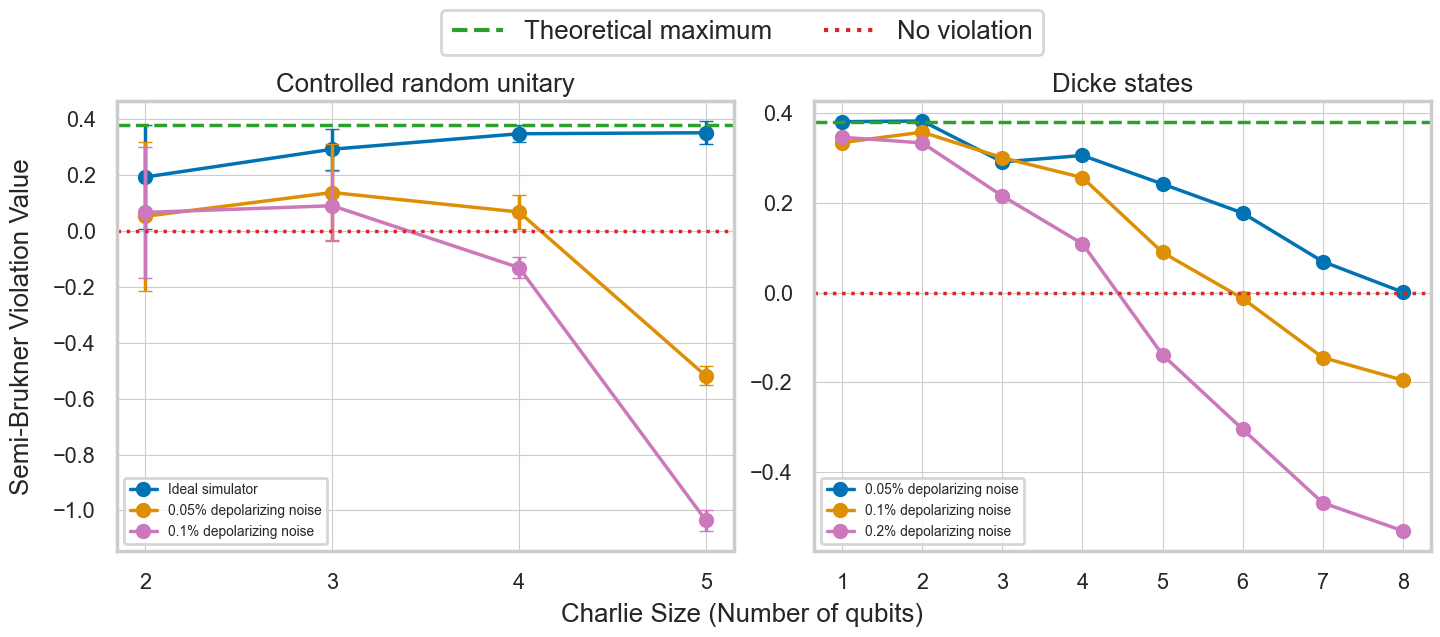

In [288]:
# Read in controlled random unitary data.
random_unitary_friend_sizes = list(range(2, 6))
with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res.pkl"), "rb") as handle:
    random_unitary_ideal = pickle.load(handle)

with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res_0_005dep.pkl"), "rb") as handle:
    random_unitary_depolarizing_005 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "random_unitary", "random_unitary_res_0_01dep.pkl"), "rb") as handle:
    random_unitary_depolarizing_01 = pickle.load(handle)

# Read in Dicke state data.
dicke_state_friend_sizes = list(range(1, 9))
with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_005dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_005 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_01dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_01 = pickle.load(handle)

with open(os.path.join(DATA_PATH, "dicke_states", "dicke_states_res_0_02dep.pkl"), "rb") as handle:
    dicke_states_depolarizing_02 = pickle.load(handle)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("colorblind", n_colors=8)

marker="o"
marker_size = 10
linestyle = "-"
line_width = 2.5

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), label="Ideal simulator", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_ideal, axis=0), yerr=np.std(random_unitary_ideal, axis=0), fmt="none", capsize=5, color=palette[0], elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), label="0.05% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_005, axis=0), yerr=np.std(random_unitary_depolarizing_005, axis=0), fmt="none", color=palette[1], capsize=5, elinewidth=line_width)

axs[0].plot(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), label="0.1% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)
axs[0].errorbar(random_unitary_friend_sizes, np.mean(random_unitary_depolarizing_01, axis=0), yerr=np.std(random_unitary_depolarizing_01, axis=0), fmt="none", capsize=5, color=palette[4], elinewidth=line_width)

axs[0].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[0].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[0].set_title("Controlled random unitary", fontsize="xx-large")
axs[0].set_xticks(random_unitary_friend_sizes)
axs[0].grid(True)

axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_005, label="0.05% depolarizing noise", marker=marker, markersize=marker_size, color=palette[0], linestyle=linestyle, linewidth=line_width)
axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_01, label="0.1% depolarizing noise", marker=marker, markersize=marker_size, color=palette[1], linestyle=linestyle, linewidth=line_width)
axs[1].plot(dicke_state_friend_sizes, dicke_states_depolarizing_02, label="0.2% depolarizing noise", marker=marker, markersize=marker_size, color=palette[4], linestyle=linestyle, linewidth=line_width)

axs[1].axhline(0.380364, color="tab:green", linestyle="dashed", label="_nolegend_", linewidth=line_width)
axs[1].axhline(0, color="tab:red", linestyle="dotted", label="_nolegend_", linewidth=line_width)
axs[1].set_title("Dicke states", fontsize="xx-large")
axs[1].set_xticks(dicke_state_friend_sizes)
axs[1].grid(True)

theoretical_max_handle = mlines.Line2D([], [], color="tab:green", linestyle="dashed", linewidth=3, label="Theoretical maximum")
no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=3, label="No violation")

fig.legend([theoretical_max_handle, no_violation_handle], ["Theoretical maximum", "No violation"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize="xx-large")

fig.text(0.5, 0.02, "Charlie Size (Number of qubits)", ha="center", va="center", fontsize="xx-large")
fig.text(0.02, 0.5, "Semi-Brukner Violation Value", ha="center", va="center", rotation="vertical", fontsize="xx-large")

axs[0].legend()
axs[1].legend()

for ax in np.ravel(axs):
    ax.tick_params(axis="x", labelsize="x-large")
    ax.tick_params(axis="y", labelsize="x-large")    

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.savefig("controlled_random_unitary_vs_dicke_state.pdf", bbox_inches="tight")

plt.show()

## Running experiments

### Running simulators

#### Strategy: Majority Vote

In [89]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="ideal_simulator",
    strategy="majority_vote",
)

# Depolarizing noise (1%)
noise_model = depolarizing_noise_model(error=0.01)
depolarizing_1perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_1perc",    
    strategy="majority_vote",    
)

# Depolarizing noise (2%)
noise_model = depolarizing_noise_model(error=0.02)
depolarizing_2perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_2perc",
    strategy="majority_vote",    
)

# Depolarizing noise (3%)
noise_model = depolarizing_noise_model(error=0.03)
depolarizing_3perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_3perc",
    strategy="majority_vote",    
)

friend_size=1
semi_brukner=0.4012000000000002 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simulator_20240312-090228/ideal_simulator_qubits_1_trial_1_shots_10000.pickle
semi_brukner=0.37440000000000007 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simulator_20240312-090228/ideal_simulator_qubits_1_trial_2_shots_10000.pickle
semi_brukner=0.39579999999999993 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simulator_20240312-090228/ideal_simulator_qubits_1_trial_3_shots_10000.pickle
semi_brukner=0.3819999999999997 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simulator_20240312-090228/ideal_simulator_qubits_1_trial_4_shots_10000.pickle
semi_brukner=0.3642000000000003 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simulator_20240312-090228/ideal_simulator_qubits_1_trial_5_shots_10000.pickle
semi_brukner=0.39620000000000033 -- is violated: True
Writing data to: ../data/majority_vote_ideal_simul

#### Strategy: Random

In [22]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="ideal_simulator",
    strategy="random",
)

# Depolarizing noise (1%)
noise_model = depolarizing_noise_model(error=0.01)
depolarizing_1perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_1perc",    
    strategy="random",    
)

# Depolarizing noise (2%)
noise_model = depolarizing_noise_model(error=0.02)
depolarizing_2perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_2perc",
    strategy="random",    
)

# Depolarizing noise (3%)
noise_model = depolarizing_noise_model(error=0.03)
depolarizing_3perc_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    backend_name="depolarizing_3perc",
    strategy="random",    
)

friend_size=1
semi_brukner=0.3847999999999998 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_1_shots_10000.pickle
semi_brukner=0.3734000000000002 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_2_shots_10000.pickle
semi_brukner=0.38739999999999997 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_3_shots_10000.pickle
semi_brukner=0.3860000000000001 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_4_shots_10000.pickle
semi_brukner=0.367 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_5_shots_10000.pickle
semi_brukner=0.3770000000000002 -- is violated: True
Writing data to: ../data/random_ideal_simulator_20240312-150903/ideal_simulator_qubits_1_trial_6_sho

### Running fake devices

#### Strategy: Majority Vote

In [185]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000

# FakeKolkataV2
backend = fake_provider.FakeKolkataV2()
noise_model = NoiseModel.from_backend(backend)
fake_kolkata_results = run_experiment(
    backend=backend,
    backend_name="fake_kolkata",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,
    strategy="majority_vote",        
)

# FakeHanoiV2
backend = fake_provider.FakeHanoiV2()
noise_model = NoiseModel.from_backend(backend)
fake_hanoi_results = run_experiment(
    backend=backend,
    backend_name="fake_hanoi",    
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,    
    strategy="majority_vote",    
)

# FakeCairoV2
backend = fake_provider.FakeCairoV2()
noise_model = NoiseModel.from_backend(backend)
fake_cairo_results = run_experiment(
    backend=backend,
    backend_name="fake_cairo",    
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,    
    strategy="majority_vote",    
)

# FakeMumbaiV2
backend = fake_provider.FakeMumbaiV2()
noise_model = NoiseModel.from_backend(backend)
fake_mumbai_results = run_experiment(
    backend=backend,
    backend_name="fake_mumbai",    
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,    
    strategy="majority_vote",    
)

friend_size=1
semi_brukner=0.2136 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_trial_1_shots_10000.pickle
semi_brukner=0.2115999999999998 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_trial_2_shots_10000.pickle
semi_brukner=0.22319999999999984 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_trial_3_shots_10000.pickle
semi_brukner=0.2163999999999997 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_trial_4_shots_10000.pickle
semi_brukner=0.22460000000000013 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_trial_5_shots_10000.pickle
semi_brukner=0.19740000000000002 -- is violated: True
Writing data to: ../data/majority_vote_fake_kolkata_20240316-095152/fake_kolkata_qubits_1_tr

#### Strategy: Random

In [56]:
# Parameters for all plots
friend_sizes = range(1, 13)
num_trials = 10
shots = 10_000

# FakeKolkataV2
backend = fake_provider.FakeKolkataV2()
noise_model = NoiseModel.from_backend(backend)
fake_kolkata_results = run_experiment(
    backend=backend,
    backend_name="fake_kolkata",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,
    strategy="random",        
)

# FakeHanoiV2
backend = fake_provider.FakeHanoiV2()
noise_model = NoiseModel.from_backend(backend)
fake_hanoi_results = run_experiment(
    backend=backend,
    backend_name="fake_hanoi",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,
    strategy="random",    
)

# FakeCairoV2
backend = fake_provider.FakeCairoV2()
noise_model = NoiseModel.from_backend(backend)
fake_cairo_results = run_experiment(
    backend=backend,
    backend_name="fake_cairo",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,
    strategy="random",    
)

# FakeMumbaiV2
backend = fake_provider.FakeMumbaiV2()
noise_model = NoiseModel.from_backend(backend)
fake_mumbai_results = run_experiment(
    backend=backend,
    backend_name="fake_mumbai",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=True,
    optimize=True,
    strategy="random",    
)

friend_size=1
semi_brukner=0.2816000000000001 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_1_shots_10000.pickle
semi_brukner=0.26900000000000013 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_2_shots_10000.pickle
semi_brukner=0.25459999999999994 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_3_shots_10000.pickle
semi_brukner=0.27200000000000024 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_4_shots_10000.pickle
semi_brukner=0.2966000000000002 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_5_shots_10000.pickle
semi_brukner=0.21720000000000006 -- is violated: True
Writing data to: ../data/random_fake_kolkata_20240313-013942/fake_kolkata_qubits_1_trial_6_shots_10000.pickle
semi

### Running hardware

In [25]:
IBM_PROVIDER_TOKEN="f93ccee55d555d956b5bd12641edb2b79f29c28235f064dccb3cfba3109d144271ce5a31fa05b26430abe31be8e87cf50f542cdf84abe3473c2f58fa7a1f56c5"

QiskitRuntimeService.save_account(channel="ibm_quantum", token=IBM_PROVIDER_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

# Parameters for all plots
friend_sizes = range(1, 9)
num_trials = 5
shots = 10_000

In [ ]:
# Kolkata hardware data
backend = service.backend("ibmq_kolkata")
noise_model = NoiseModel.from_backend(backend)
kolkata_results = run_experiment(
    backend=backend,
    noise_model=None,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    optimize=True,
)

# MISC

In [ ]:
IBM_PROVIDER_TOKEN="f93ccee55d555d956b5bd12641edb2b79f29c28235f064dccb3cfba3109d144271ce5a31fa05b26430abe31be8e87cf50f542cdf84abe3473c2f58fa7a1f56c5"

QiskitRuntimeService.save_account(channel="ibm_quantum", token=IBM_PROVIDER_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

One can use this to run the experiment and save the data.

In [49]:
friend_sizes = range(1, 5)
num_trials=1
shots = 10_000
backend = fake_provider.FakeKolkataV2()
noise_model = None
results = run_experiment(
    backend=backend,
    backend_name="fake_mumbai",
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
    save=False,
    optimize=True,
    strategy="majority_vote",    
)

friend_size=1
semi_brukner=0.13939999999999975 -- is violated: True
friend_size=2
semi_brukner=0.15000000000000036 -- is violated: True
friend_size=3
semi_brukner=0.17200000000000015 -- is violated: True
friend_size=4
semi_brukner=0.12619999999999987 -- is violated: True


Alternatively, you can use the content below to rapidly iterate over fake devices.

In [24]:
# Parameters for all plots
friend_sizes = range(1, 6)
num_trials = 1
shots = 10_000
optimize = True
noise_model = None
strategy = "majority_vote"
verbose = True

#backend = fake_provider.FakeAlgiers()
#backend = fake_provider.FakeCairoV2()
#backend = fake_provider.FakeHanoiV2()
#backend = fake_provider.FakeKolkataV2()
#backend = fake_provider.FakeMumbaiV2()
#backend = service.backend("ibm_algiers")
#backend = service.backend("ibmq_kolkata")

#noise_model = NoiseModel.from_backend(backend)

pm = PassManager()
pm.append([
    passes.Optimize1qGatesDecomposition(),
])

all_results = {
    fs: {inequality: [] for inequality in ["semi_brukner"]}
    for fs in friend_sizes
}

for friend_size in friend_sizes:
    print(f"{friend_size=}")
    for trial in range(num_trials):
        all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]
        results = {}
        circuits = {}
        for alice, bob in all_experiment_combos:
            circuits[(alice, bob)] = ewfs(alice, bob, strategy=strategy, angles=ANGLES, beta=BETA, charlie_size=friend_size, debbie_size=1)

        if optimize:
            # Optimize qubit initial layout:
            #initial_layout = calculate_optimal_qubit_layout(charlie_size=friend_size)
            # NOTE: We can use this section to adopt to the topology as necessary.
            alice_bob_qubits = [2, 1]
            debbie_qubits = [0]
            charlie_qubits = range(3, 14)
            initial_layout = alice_bob_qubits + charlie_qubits[:friend_size] + debbie_qubits
            transpiled_circuits = transpile(
                list(circuits.values()),
                backend=backend,
                optimization_level=0,
                initial_layout=initial_layout,
            )
            # Optimize single-qubit gate decompositions:
            transpiled_circuits = pm.run(transpiled_circuits)    
        else:
            # Don't apply any optimizations:
            transpiled_circuits = transpile(
                list(circuits.values()),
                backend=backend,
                optimization_level=0,
                initial_layout=None,                
            )            
            
        circuits = {key: circuit for key, circuit in zip(circuits.keys(), transpiled_circuits)}

        result = backend.run(list(circuits.values()), shots=shots).result()

        # Convert counts to probabilities.
        for key, count in zip(circuits.keys(), result.get_counts()):
            probabilities = {k[::-1]: v / shots for k, v in count.items()}
            results[key] = probabilities

        violations = compute_violations(results=results, charlie_size=friend_size, debbie_size=1, strategy=strategy, verbose=verbose)
        for key in violations:
            all_results[friend_size][key].append(violations[key])

friend_size=1
semi_brukner=0.11900000000000022 -- is violated: True
friend_size=2
semi_brukner=0.12619999999999987 -- is violated: True
friend_size=3
semi_brukner=0.13039999999999985 -- is violated: True
friend_size=4
semi_brukner=0.10780000000000012 -- is violated: True
friend_size=5
semi_brukner=0.10280000000000022 -- is violated: True
